# Customer Segmentation Using RFM Analysis and K-Means Clustering

## Project Overview

This project segments customers based on their purchasing behavior using RFM analysis and K-Means clustering. The goal is to identify meaningful customer groups based on recency, purchase frequency, and spending, and to provide business recommendations for each segment.

##  Import Libraries

In [114]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score

os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

##  Data Wrangling and Cleaning

In [115]:
def wrangle(filepath):
    df = pd.read_excel(filepath)

    df = df.dropna(subset=["CustomerID"])
    df = df.drop_duplicates()

    mask = (df["Quantity"] > 0) & (df["UnitPrice"] > 0)
    df = df[mask]

    df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

    return df

In [116]:
df = wrangle("Online Retail.xlsx")

##  Data Exploration

In [117]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [118]:
print(df.shape)

(392692, 9)


In [119]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB
None


In [120]:
df.isnull().sum()/len(df)*100

InvoiceNo      0.0
StockCode      0.0
Description    0.0
Quantity       0.0
InvoiceDate    0.0
UnitPrice      0.0
CustomerID     0.0
Country        0.0
TotalPrice     0.0
dtype: float64

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
df[df.duplicated(keep=False)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice


In [123]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [124]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice


In [125]:
df[df["UnitPrice"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice


In [126]:
df[df["UnitPrice"] == 0].shape

(0, 9)

### Observation

The cleaned dataset contains 392,692 transactions. Missing customer records, duplicates, cancellations, and transactions with non-positive quantities or unit prices were removed. The remaining data contains valid purchase transactions for customer segmentation.

 RFM Feature Engineering

RFM analysis summarizes customer purchasing behavior using:

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique transactions made by the customer.
- **Monetary:** Total amount spent by the customer.

In [127]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [128]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [129]:
recency = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()


In [130]:

recency["Recency"] = (reference_date - recency["InvoiceDate"]).dt.days
recency = recency[["CustomerID", "Recency"]]

In [131]:
recency.head()

,CustomerID,Recency
0,12346.0,326
1,12347.0,2
2,12348.0,75
3,12349.0,19
4,12350.0,310


In [132]:
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()


In [133]:
frequency.rename(columns={"InvoiceNo": "Frequency"}, inplace=True)


In [134]:
frequency.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [135]:
monetary = df.groupby("CustomerID")["TotalPrice"].sum().reset_index()

In [136]:
monetary.rename(columns={"TotalPrice": "Monetary"}, inplace=True)

In [137]:
monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [138]:
rfm = recency.merge(frequency, on="CustomerID")

In [139]:
rfm = rfm.merge(monetary, on="CustomerID")

In [140]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


##  RFM Distribution and Outlier Analysis

In [141]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


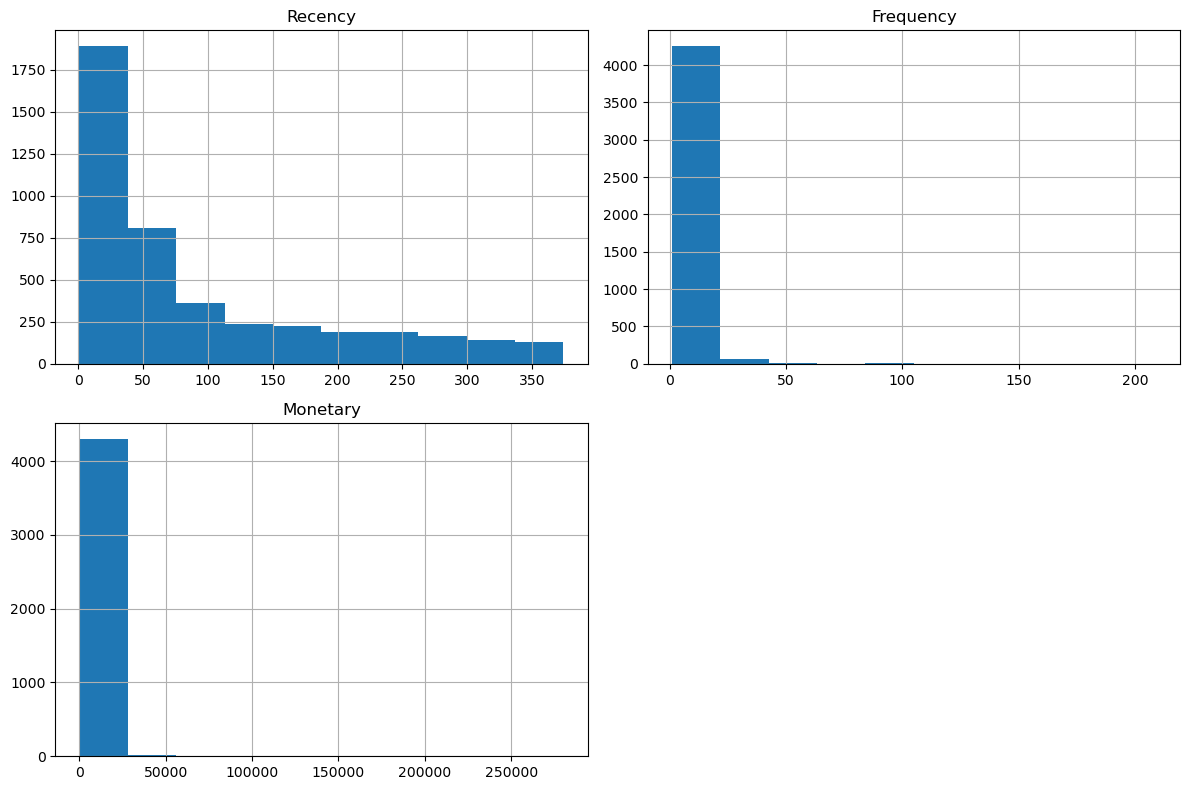

In [142]:
rfm[["Recency", "Frequency", "Monetary"]].hist(figsize=(12, 8))
plt.tight_layout()
plt.show();

### Observation

The RFM features have different distributions and scales. Frequency and Monetary are strongly right-skewed, with a small number of customers having very high purchase frequency and spending. Recency is also right-skewed, though less severely. These differences should be addressed before applying K-Means clustering.

In [143]:
rfm[["Recency", "Frequency", "Monetary"]].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

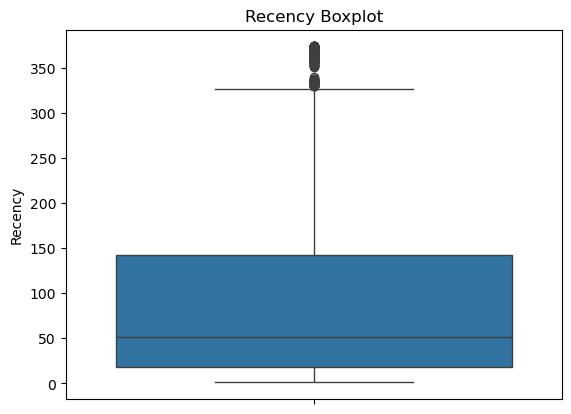

In [144]:
sns.boxplot(y=rfm["Recency"])
plt.title("Recency Boxplot")
plt.show();

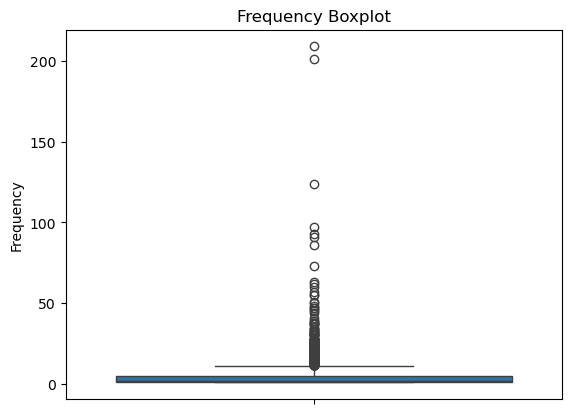

In [145]:
sns.boxplot(y=rfm["Frequency"])
plt.title("Frequency Boxplot")
plt.show();

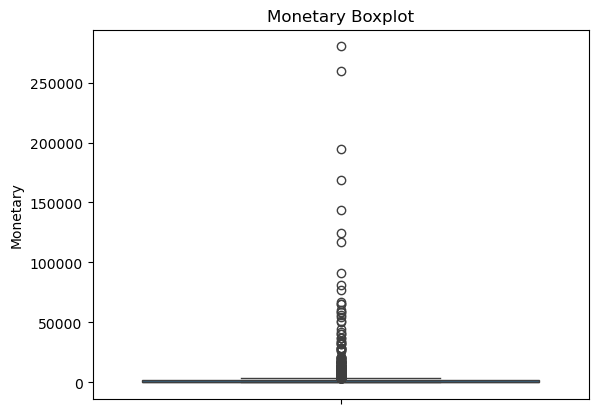

In [146]:
sns.boxplot(y=rfm["Monetary"])
plt.title("Monetary Boxplot")
plt.show();

### Observation

All three RFM features contain outliers. Frequency and Monetary show particularly large extreme values, representing customers with unusually frequent purchases or high spending. Rather than removing these valuable customers, a log transformation will be applied to reduce the effect of extreme values and skewness.

##  Data Transformation and Scaling

In [147]:
rfm_log = np.log1p(
    rfm[["Recency", "Frequency", "Monetary"]]
)

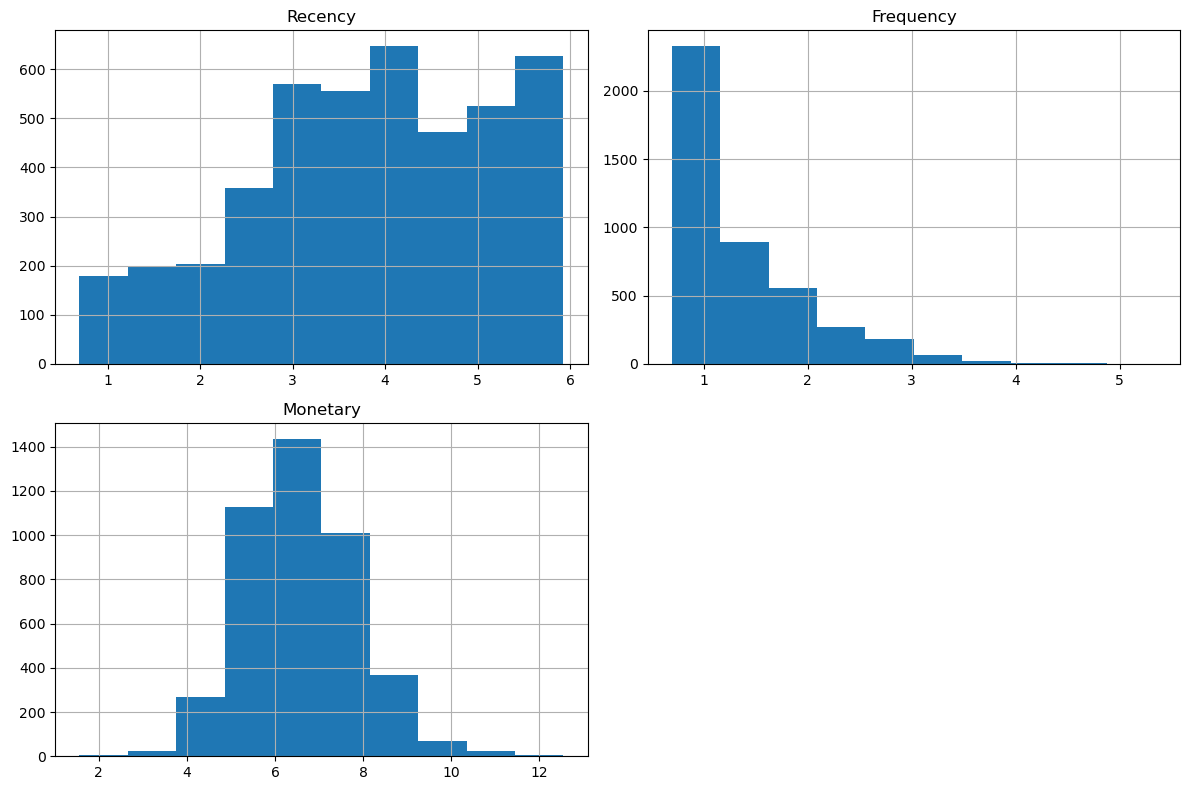

In [148]:
rfm_log.hist(figsize=(12, 8))
plt.tight_layout()
plt.show();

### Observation

The log transformation reduced the skewness and impact of extreme values, particularly for Frequency and Monetary, making the RFM features more suitable for K-Means clustering.

In [149]:
X = rfm_log.copy()
X.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [150]:
X_summary = X.aggregate(["mean", "std"])
X_summary

,Recency,Frequency,Monetary
mean,3.830734,1.345582,6.588562
std,1.340261,0.683104,1.258438


In [151]:
ss = StandardScaler()
X_scaled_data = ss.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_data,columns=X.columns)
X_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


In [152]:
X_scaled_summary = X_scaled.aggregate(["mean","std"]).astype(int)
X_scaled_summary

,Recency,Frequency,Monetary
mean,0,0,0
std,1,1,1


##  K-Means Model Selection

Different values of K are evaluated using inertia and silhouette score to determine an appropriate number of customer clusters.

In [153]:
n_clusters = range(2,13)

inertia_errors = []
silhouette_scores = []

for k in n_clusters:
    model = make_pipeline(StandardScaler(),KMeans(n_clusters=k,random_state=42))
    model.fit(X);
    inertia_errors.append(model.named_steps["kmeans"].inertia_)
    silhouette_scores.append(silhouette_score(X,model.named_steps["kmeans"].labels_))

print("Inertia:",inertia_errors[:3])
print("Silhouette:",silhouette_scores[:3])

    

Inertia: [6483.702440065324, 4869.681157060153, 3939.40317591255]
Silhouette: [np.float64(0.40743196604007514), np.float64(0.3113814369924357), np.float64(0.3282175167561856)]


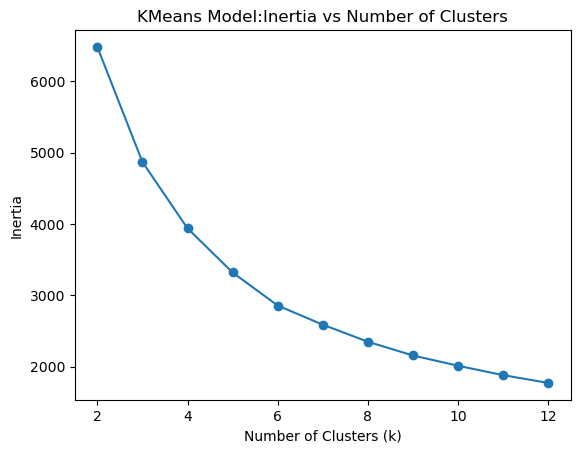

In [154]:
plt.plot(n_clusters, inertia_errors, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("KMeans Model:Inertia vs Number of Clusters")
plt.show();

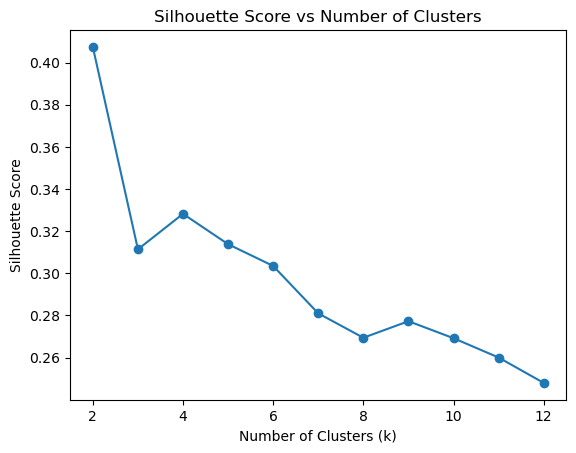

In [155]:
plt.plot(n_clusters, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show();

### Observation

The silhouette score is highest at **K = 2**, indicating the strongest statistical separation. However, **K = 4** provides a better balance between cluster separation and meaningful customer segmentation, allowing the business to identify four distinct customer groups.


In [156]:
final_model = make_pipeline(StandardScaler(),KMeans(n_clusters=4,random_state=42))
final_model.fit(X);

In [157]:
labels = final_model.named_steps["kmeans"].labels_
print(labels[:5])

[2 1 2 0 3]


In [158]:
rfm["Cluster"] = labels

In [159]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,2
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,3


##  Customer Cluster Visualization

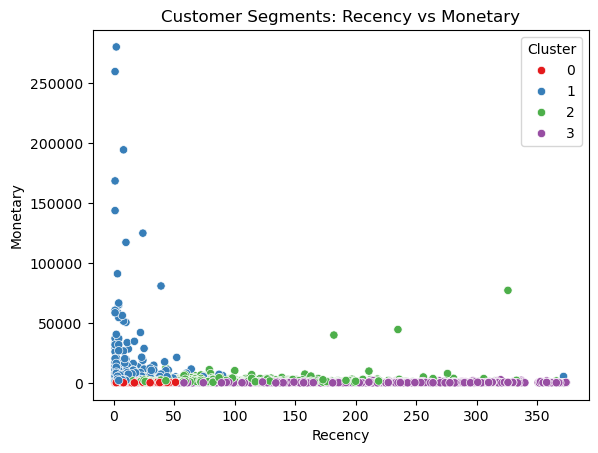

In [160]:
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.show();

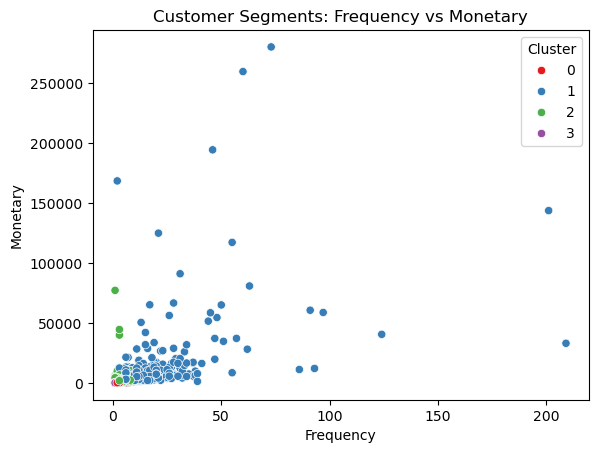

In [161]:
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.show();

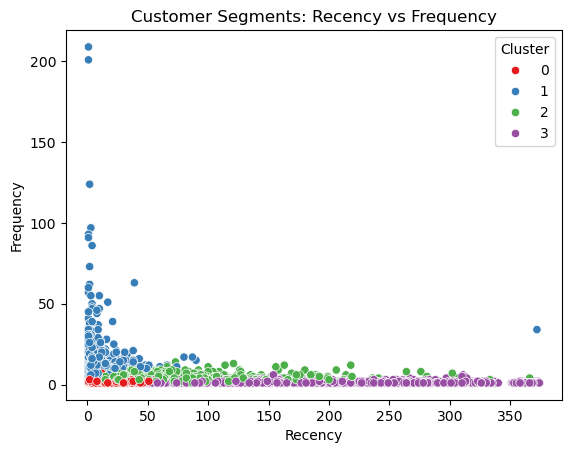

In [162]:
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segments: Recency vs Frequency")
plt.show();

### Cluster Interpretation

- **Cluster 0 – Recent/Occasional Customers:** Purchased recently but have low purchase frequency and spending.
- **Cluster 1 – Loyal High-Value Customers:** Purchase recently and frequently, with the highest spending.
- **Cluster 2 – Regular Customers:** Moderate recency, frequency, and spending.
- **Cluster 3 – At-Risk/Inactive Customers:** Have not purchased recently, purchase rarely, and have low spending.

In [163]:
cluster_summary= rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

In [164]:
cluster_summary_log = X.groupby(labels).mean()
cluster_summary_log.index.name = "Cluster"
cluster_summary_log = cluster_summary_log.reset_index()

fig = px.bar(
    cluster_summary_log,
    x="Cluster",
    y=["Recency", "Frequency", "Monetary"],
    barmode="group",
    title="Average RFM Values by Customer Cluster"
)

fig.show();

In [165]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()
cluster_counts

Cluster
0     856
1     707
2    1185
3    1590
Name: count, dtype: int64

In [166]:
fig = px.bar(
    x=cluster_counts.index,
    y=cluster_counts.values,
    labels={"x": "Cluster", "y": "Number of Customers"},
    title="Number of Customers in Each Cluster"
)

fig.show();

### Business Recommendations

- **Cluster 0 – Recent/Occasional Customers:** Encourage repeat purchases through personalized offers, product recommendations, and follow-up promotions.

- **Cluster 1 – Loyal High-Value Customers:** Focus on retention with loyalty rewards, exclusive offers, and early access to new products.

- **Cluster 2 – Regular Customers:** Increase purchase frequency and spending through targeted promotions, bundles, and cross-selling.

- **Cluster 3 – At-Risk/Inactive Customers:** Use re-engagement campaigns, special discounts, and personalized reminders to encourage them to return.

## Conclusion

The RFM and K-Means analysis identified four distinct customer segments with different purchasing behaviors. The results provide actionable insights that can help the business improve customer retention, increase engagement, and develop targeted marketing strategies for each customer group.